In [1]:
# local imports
from picell_1d import *
from dist_gen import *
# external imports
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import curve_fit

In [2]:
sweep_params: dict = {
	"x_min":			-0.00005,
	"x_max":			 0.00005,
	"v_min":			-10,
	"v_max":			 10,
	"steps_per_pd":		 75,
	"n_frames":			 500,
	"window_res":		 250,
	"f_cells_per_lam_D": 2000,
    "max_field_res":	 5000,
    "fixed_ions":		 False,
    "two_stream":		 False,
	"rho_lim_scale":	 15,
	"E_lim_scale":		 10,
	"ec_lim_margin":	 10,
	"N_e":				 50000,
	"N_i":				 50000,
	"x_pert_amp_e":		 0.05,
	"x_pert_amp_i":		 0,
    "x_pert_mode":		 1,
	"v_th_ratio_e":		 1/5000,
    "v_th_ratio_i":		 1/5000,
    "v_dr_ratio_e":		 0,
	"v_dr_ratio_i":		 0,
    "E_solver":			 1,
    "integration":		 0
}

#pic_1d(sweep_params, show_plot = True, verbose = True)

In [3]:
chg_ratio_arr = np.linspace(-0.9, 0.9, 100)
N_total = 40000
N_e_arr = np.round((N_total/2) * (1-chg_ratio_arr)).astype(int)
N_i_arr = N_total - N_e_arr

trials_per_val = 1
N_samples = trials_per_val * len(chg_ratio_arr)

sweep_data = {
	"q_tot":		[],
	"chg_ratios":	[],
	"frequencies":	[],
	"decays":		[]
}

# sweeping loop
for i in range(len(chg_ratio_arr)):
	sweep_params["N_e"] = N_e_arr[i]
	sweep_params["N_i"] = N_i_arr[i]
	freqs = []
	decays = []
	for j in range(trials_per_val):
		sample_idx = i * trials_per_val + j + 1
		print(f"\nSample {sample_idx}/{N_samples}")
		result = pic_1d(sweep_params, show_plot = False, verbose = False)
		freqs.append(result["w_obs"])
		decays.append(result["obs_decay_coeff"])
	sweep_data["q_tot"].append((N_i_arr[i]-N_e_arr[i]) * e)
	sweep_data["chg_ratios"].append(chg_ratio_arr[i])
	sweep_data["frequencies"].append(np.mean(freqs))
	sweep_data["decays"].append(np.mean(decays))


Sample 1/100
Current frame: 500 / 500                     
Sample 2/100
Current frame: 500 / 500                     
Sample 3/100
Current frame: 500 / 500                     
Sample 4/100
Current frame: 500 / 500                     
Sample 5/100
Current frame: 500 / 500                     
Sample 6/100
Current frame: 500 / 500                     
Sample 7/100
Current frame: 500 / 500                     
Sample 8/100
Current frame: 500 / 500                     
Sample 9/100
Current frame: 500 / 500                     
Sample 10/100
Current frame: 500 / 500                     
Sample 11/100
Current frame: 500 / 500                     
Sample 12/100
Current frame: 500 / 500                     
Sample 13/100
Current frame: 500 / 500                     
Sample 14/100
Current frame: 500 / 500                     
Sample 15/100
Current frame: 500 / 500                     
Sample 16/100
Current frame: 500 / 500                     
Sample 17/100
Current frame: 500 / 500          

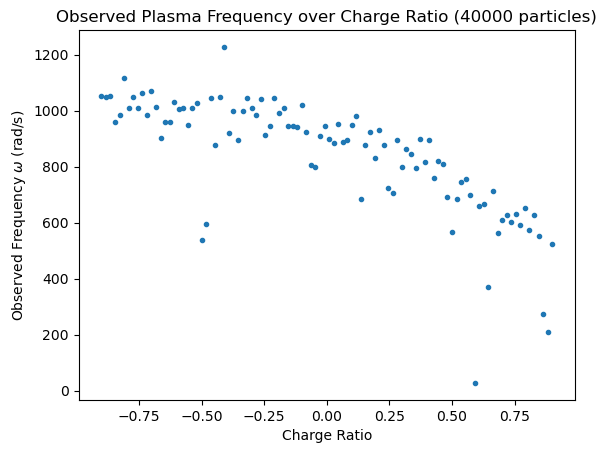

In [4]:
plt.scatter(sweep_data["chg_ratios"], np.sqrt(sweep_data["frequencies"]), marker=".", label = "Samples")
plt.title(f"Observed Plasma Frequency over Charge Ratio ({N_total} particles)")
plt.xlabel("Charge Ratio")
plt.ylabel("Observed Frequency $\omega$ (rad/s)")

if fixed_ions:
	plt.savefig(r"outputs\sweeps\chg_sweep_omega.png")
else:
	plt.savefig(r"outputs\sweeps\chg_sweep_omega_i.png")

C:\Users\Dugan\AppData\Local\Temp\ipykernel_17684\1018255143.py:1: RuntimeWarning: invalid value encountered in sqrt
  plt.scatter(sweep_data["chg_ratios"], np.sqrt(sweep_data["decays"]), marker=".", label = "Samples")


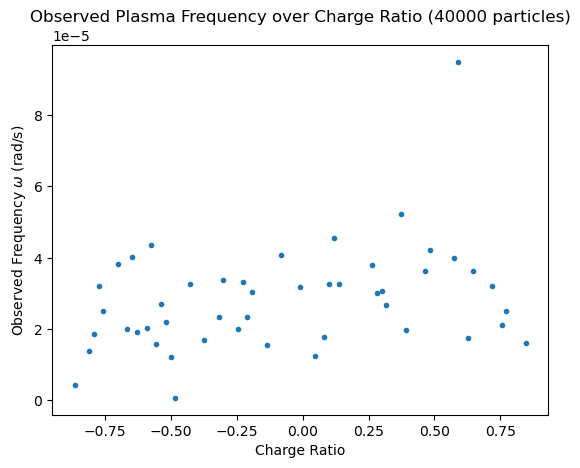

In [ ]:
plt.scatter(sweep_data["chg_ratios"], np.sqrt(sweep_data["decays"]), marker=".", label = "Samples")
plt.title(f"Observed Decay Coeffs. over Charge Ratio ({N_total} particles)")
plt.xlabel("Charge Ratio")
plt.ylabel("Observed Decay $\gamma$")
if fixed_ions:
	plt.savefig(r"outputs\sweeps\chg_sweep_gamma.png")
else:
	plt.savefig(r"outputs\sweeps\chg_sweep_gamma_i.png")